# Plot Garmin data

## Sources:
- [Analysis of Running Activities from Garmin Watch Using Python](https://towardsdatascience.com/analysis-of-runing-activities-from-garmin-watch-using-python-99609f83314e)

## Import modules

In [22]:
# import internal modules
# from typing import List, Set, Dict, TypedDict, Tuple, Optional, Union
from pathlib import Path

# import 3rd-party modules
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# import local modules

## Read data

In [74]:
# set csv path
football_activities_df_path = Path("assets/data/garmin_data/football_1_year_cleaned.csv")

# read csv into dataframe
football_activities_df = pd.read_csv(football_activities_df_path, parse_dates=True)

football_activities_df.head()

,Date,Title,Distance,Calories,Time,Avg HR,Max HR,Aerobic TE,Avg Run Cadence,Max Run Cadence,...,Total Descent,Avg Stride Length,Best Lap Time,Number of Laps,Max Temp,Moving Time,Elapsed Time,Min Elevation,Max Elevation,Date_yy-mm-dd
0,2022-08-07 13:49:30,Grimbergen Football,8.90,1381.0,165.166667,140,192,5.0,50.0,232.0,...,1.0,1.02,11.631117,9,0.0,109.983333,165.166667,40.0,42.0,2022-08-07
1,2022-07-31 16:41:23,Grimbergen Football,0.62,375.0,30.216667,152,185,3.3,27.0,232.0,...,NaN,0.75,30.221783,1,0.0,13.050000,30.216667,40.0,42.0,2022-07-31
2,2022-07-31 14:20:23,Grimbergen Football,6.71,775.0,99.483333,129,172,3.0,64.0,248.0,...,5.0,1.07,12.176900,7,0.0,82.616667,99.500000,40.0,44.0,2022-07-31
3,2022-07-24 14:43:01,Grimbergen Football,4.96,854.0,92.166667,137,180,3.4,54.0,232.0,...,9.0,0.98,11.061750,5,0.0,67.150000,109.933333,40.0,45.0,2022-07-24
4,2022-07-17 13:53:02,Grimbergen Football,9.09,1479.0,142.833333,150,195,5.0,67.0,248.0,...,18.0,0.94,4.867350,10,0.0,112.666667,143.266667,40.0,45.0,2022-07-17


In [78]:
football_activities_df.columns

Index(['Date', 'Title', 'Distance', 'Calories', 'Time', 'Avg HR', 'Max HR',
       'Aerobic TE', 'Avg Run Cadence', 'Max Run Cadence', 'Avg Speed',
       'Max Speed', 'Total Ascent', 'Total Descent', 'Avg Stride Length',
       'Best Lap Time', 'Number of Laps', 'Max Temp', 'Moving Time',
       'Elapsed Time', 'Min Elevation', 'Max Elevation', 'Date_yy-mm-dd'],
      dtype='object')

[Text(0.5, 1.0, 'Average HR Distribution')]

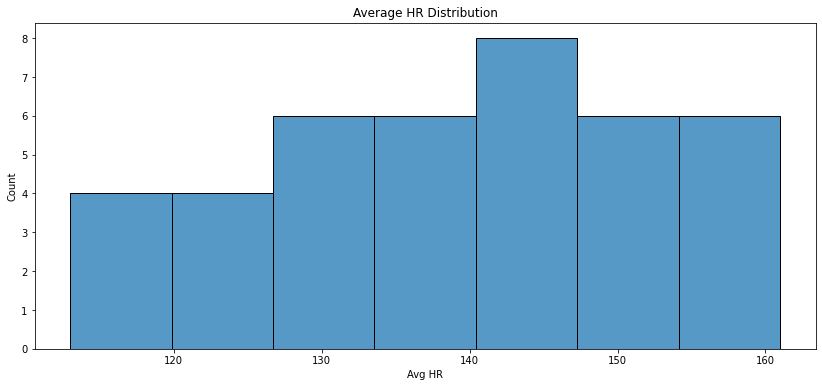

In [4]:
plt.figure(figsize=(14,6))
sns.histplot(data = football_activities_df, x='Avg HR').set(title = 'Average HR Distribution')

In [41]:
dates = football_activities_df["Date_yy-mm-dd"].unique()
dates.sort()
dates

array(['2021-07-04', '2021-07-11', '2021-07-18', '2021-07-25',
       '2021-08-08', '2021-08-15', '2021-08-22', '2021-08-25',
       '2021-08-28', '2021-08-29', '2021-09-19', '2021-09-26',
       '2021-10-10', '2021-10-17', '2021-10-31', '2021-11-07',
       '2021-11-14', '2021-11-21', '2022-02-20', '2022-03-06',
       '2022-03-13', '2022-04-24', '2022-05-01', '2022-06-02',
       '2022-06-05', '2022-06-09', '2022-06-12', '2022-07-03',
       '2022-07-10', '2022-07-17', '2022-07-24', '2022-07-31',
       '2022-08-07'], dtype=object)

In [43]:
football_activities_df[football_activities_df["Date_yy-mm-dd"] == dates[0]]

,Unnamed: 0,Date,Title,Distance,Calories,Time,Avg HR,Max HR,Aerobic TE,Avg Run Cadence,...,Total Descent,Avg Stride Length,Best Lap Time,Number of Laps,Max Temp,Moving Time,Elapsed Time,Min Elevation,Max Elevation,Date_yy-mm-dd
38,38,2021-07-04 15:51:38,Grimbergen Football,0.00,NaN,0.088333,133,134,NaN,NaN,...,NaN,0.00,0.013333,3,0.0,0.063333,0.088333,44.0,44.0,2021-07-04
39,39,2021-07-04 14:24:02,Grimbergen Football,6.58,719.0,72.183333,142,185,3.5,79.0,...,5.0,1.16,6.449733,7,0.0,67.883333,83.800000,40.0,44.0,2021-07-04


In [ ]:
"""
Idea to make text animation put animation in a fct and call fct several times per date
"""

import bpy
import pandas as pd
import numpy as np
from mathutils import Vector, Matrix

from bpy.app.handlers import persistent

# import local modules

# =====================================================================
# Define functions
# =====================================================================


def reset_scene(collection=None):
    """
    Function to remove all objects collections inside "Collection"
    """
    # # select and delete everything on the viewport (to reset)
    # go into object mode
    # bpy.ops.object.mode_set(mode='OBJECT', toggle=False)
    bpy.ops.object.select_all(action='SELECT')
    bpy.ops.object.delete(use_global=False)

    # get Collection "Collection" if no collection provided
    if collection is None:
        collection = bpy.data.collections['Collection']
    
    ## remove and unlink all objects in collection
    # for collection_obj in collection.all_objects:
            # bpy.data.objects.remove(collection_obj, do_unlink=True)

    # remove all children collections
    for child_collection in collection.children:
            bpy.data.collections.remove(child_collection)


def create_collection(name, parent_collection=None):
    """
    Function to create a child collection
    in active collection or in parent collection if provided
    """
    
    # add new collection to the main database
    collection = bpy.data.collections.new(name=name)
    
    # link new collection to active collection or parent collection if provided
    if parent_collection is None:
        parent_collection = bpy.context.collection
    
    parent_collection.children.link(collection)
    
    return collection


def add_text(text: str, obj_name=None, collection=None):
    """
    Function to add text to the scene
    """
    
    # set object name to text string if not provided
    # obj_name = text if obj_name is None else obj_name
    obj_name = obj_name or text
    
    # create new font curve (i.e text)
    font_curve = bpy.data.curves.new(type="FONT", name=obj_name)

    # edit text
    font_curve.body = text

    # create font object from text
    font_obj = bpy.data.objects.new(name=obj_name, object_data=font_curve)

    # link font object to active collection or "Collection"
    if collection is None:
        collection = bpy.data.collections['Collection']

    collection.objects.link(font_obj)
    
    return font_obj

""""
def update_text_handler(current_text, previous_distance_linspace):
    current_frame = bpy.context.scene.frame_current
    current_text.data.body = f"{previous_distance_linspace[current_frame]:.2f}"

@persistent
def update(self):
    update_text_handler(current_text, previous_distance_linspace)
"""
"""
def update(self):
    current_frame = bpy.context.scene.frame_current
    # distance_text_obj.data.body = f"{previous_distance_linspace[current_frame]:.2f}"
    # distance_text_obj.data.body = str(current_frame)
    distance_text_obj.data.body = distance_text_obj["text_animator"]
"""
"""
def update(self):
    current_frame = bpy.context.scene.frame_current
    distance_text_obj.data.body = f"{previous_distance_linspace[current_frame]:.2f}"
"""

def update_text_handler(scene, current_text, previous_distance_linspace):
    current_frame = scene.frame_current
    current_text.data.body = f"{previous_distance_linspace[current_frame]:.2f}"
    
def register():
    bpy.app.handlers.frame_change_post.append(update)
    # bpy.app.handlers.frame_change_pre.append(update)

def unregister():
    bpy.app.handlers.frame_change_post.remove(update)

# =====================================================================
# Test functions
# =====================================================================

def main(date_idx):
    
    # global current_text
    
    NB_FRAMES = 30
    
    scene = bpy.context.scene
    scene.frame_start = 0
    scene.frame_end = NB_FRAMES
    
    if date_idx == 0:
        reset_scene()
    
    parent_collection = bpy.data.collections["Collection"]
    text_collection_name = "Text_collection"
    cube_collection_name = "Cube_collection"
    text_collection = create_collection(text_collection_name, parent_collection)
    cube_collection = create_collection(cube_collection_name, parent_collection)

    
    date_collection = create_collection("dates", text_collection)
    distance_collection = create_collection("distance", text_collection)
    
    # get collection in outliner and activate it
    layer_collection = bpy.context.view_layer.layer_collection.children['Collection'].children[cube_collection_name]
    bpy.context.view_layer.active_layer_collection = layer_collection
    
    CUBE_SIZE = 1  # size of the cubes

    football_activities_df = pd.read_csv("/Users/derrickvanfrausum/BeCode_AI/git-repos/coding-art/core/assets/data/garmin_data/football_1_year_cleaned.csv")
    
    dates = football_activities_df["Date_yy-mm-dd"].unique()
    dates.sort()
    
    # distance_texts = []
    
    for i, activity_date in enumerate([dates[date_idx]], date_idx):
        activities = football_activities_df.loc[football_activities_df["Date_yy-mm-dd"] == activity_date, ["Date_yy-mm-dd", "Distance"]]
        distance_done = 0
        animate_distance_done = 0
        previous_distance_linspace = np.zeros(NB_FRAMES)
        
        date_text_obj = add_text(activity_date, collection=date_collection)
        date_text_obj.rotation_euler[0] = 1.5708 # 90°
        date_text_obj.scale = (0.2, 0.2, 0.2)
        date_text_obj.location = (i - CUBE_SIZE/2, -CUBE_SIZE/2, -0.4)
        
        distance_text_obj = add_text(f"{distance_done:.2f}", collection=distance_collection)
        distance_text_obj.rotation_euler[0] = 1.5708 # 90°
        distance_text_obj.scale = (0.2, 0.2, 0.2)
        distance_text_obj.location = (i - CUBE_SIZE/2, -CUBE_SIZE/2, distance_done+0.4)
        
        # distance_texts.append(distance_text_obj)
    
        for activity in activities.values:
            distance = activity[1]
            # offset_location = distance/2
            # distance_done += distance
            
            # toDo: fix when CUBE_SIZE != 1
            # bpy.ops.mesh.primitive_cube_add(size=CUBE_SIZE, enter_editmode=False, align='WORLD', location=(i, 0, distance_done - distance/2), scale=(1, 1, distance))
            bpy.ops.mesh.primitive_cube_add(size=CUBE_SIZE, enter_editmode=False, align='WORLD', location=(i, 0, 0), scale=(1, 1, 1))
            # bpy.ops.mesh.primitive_cube_add(size=CUBE_SIZE, enter_editmode=False, align='WORLD', location=(i, 0, 0), scale=(1, 1, distance))
            obj = bpy.context.active_object
            
            # move origin to bottom of object (z axis)
            # new_origin = Vector([0,0,- distance_done + distance/2])
            # obj = bpy.context.active_object
            # obj.data.transform(Matrix.Translation(-new_origin))
            ## obj.matrix_world.translation += new_origin
            distance_linspace = np.linspace(0,distance,NB_FRAMES)
            for frame_nb, d in enumerate(distance_linspace):
                # distance_done += d # cool animation
                # obj.location[2] = distance_done + d/2 
                # obj.location[2] = animate_distance_done + d/2
                obj.location[2] = previous_distance_linspace[frame_nb] + d/2
                
                obj.keyframe_insert(data_path = "location", frame = frame_nb)
                obj.scale = (1,1,d)
                obj.keyframe_insert(data_path = "scale", frame = frame_nb)
            
            previous_distance_linspace += distance_linspace
            # animate_distance_done += distance
        
        for frame_nb in range(NB_FRAMES):
            # bpy.context.scene.frame_set(frame_nb)
            # distance_text_obj["text_animator"] = f"{previous_distance_linspace[frame_nb]:.2f}"
            
            
        # for distance_done in previous_distance_linspace:
            # distance_text_obj.data.body = f"{distance_done:.2f}"
            # distance_text_obj.keyframe_insert(data_path = "body", frame = frame_nb)
            distance_text_obj.location[2] = previous_distance_linspace[frame_nb]+0.4
            distance_text_obj.keyframe_insert(data_path = "location", frame = frame_nb)
            
        # current_text = distance_texts[i]
        current_text = distance_text_obj

        @persistent
        def update(scene):
            update_text_handler(scene, current_text, previous_distance_linspace)
        
        # register()
        bpy.app.handlers.frame_change_pre.append(update)
        
        """  
        distance_text_obj = add_text(f"{distance_done:.2f}", collection=distance_collection)
        distance_text_obj.rotation_euler[0] = 1.5708 # 90°
        distance_text_obj.scale = (0.2, 0.2, 0.2)
        distance_text_obj.location = (i - CUBE_SIZE/2, -CUBE_SIZE/2, distance_done+0.4)
        """
        
    # set current frame to 0
    bpy.context.scene.frame_set(0)


main(0)
main(1)
    

In [79]:
football_activities_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 23 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Date               40 non-null     object 
 1   Title              40 non-null     object 
 2   Distance           40 non-null     float64
 3   Calories           39 non-null     float64
 4   Time               40 non-null     float64
 5   Avg HR             40 non-null     int64  
 6   Max HR             40 non-null     int64  
 7   Aerobic TE         39 non-null     float64
 8   Avg Run Cadence    39 non-null     float64
 9   Max Run Cadence    39 non-null     float64
 10  Avg Speed          39 non-null     float64
 11  Max Speed          39 non-null     float64
 12  Total Ascent       32 non-null     float64
 13  Total Descent      31 non-null     float64
 14  Avg Stride Length  40 non-null     float64
 15  Best Lap Time      40 non-null     float64
 16  Number of Laps     40 non-nu

In [83]:
180/60

3.0

In [89]:
3/30*10

1.0

In [87]:
(200/60)*30

100.0

In [90]:
200 - 180/200

199.1

In [94]:
199.1/60/30*10

1.1061111111111113

In [95]:
def normalize_between_range(xs, a, b):
    """
    Function to normalize a number between a range [a,b]
    """
    min_x = np.min(xs)
    max_x = np.max(xs)
    return (b - a) * (xs - min_x)/(max_x - min_x) + a



In [96]:
normalize_between_range(football_activities_df.Calories, 0,179)

0     166.876987
1      42.430546
2      91.912232
3     101.684865
4     179.000000
5      66.058051
6     166.753283
7      59.006911
8      77.438839
9      40.327574
10     47.997236
11     28.204561
12    103.169316
13    174.670352
14     68.532135
15     17.565999
16     67.913614
17     30.554941
18    127.786455
19     98.839668
20     86.469247
21     43.420180
22      7.545957
23    116.158258
24     89.314444
25     34.637180
26      2.721493
27     22.761576
28     11.504492
29     88.943331
30    116.529371
31    100.695232
32      0.000000
33     95.994471
34    118.508639
35     94.262612
36     89.685556
37     26.472702
38           NaN
39     84.984796
Name: Calories, dtype: float64